# Actividad 2.1. ¿Cómo de importantes son los pulgares? (Angello Javier Padilla - CXO)

## Diseño del experimento

### Objetivo del experimento

Medir el efecto de inmovilizar los pulgares sobre el tiempo para atar cordones, y evaluar si hay mejora con la práctica bajo esa restricción. El tiempo de ejecución sirve como evidencia observable de dos fenómenos **a poner a prueba** (no a asumir):

1. El costo de la restricción (caída del desempeño respecto a pulgares libres).
2. Una posible mejora progresiva con la práctica (aprendizaje / adaptación motora).

Este es un **auto-experimento (n = 1)**: útil como demo pedagógica, no como inferencia poblacional sobre “el cerebro humano”.

### Hipótesis (falsables)

Con α = 0,05:

1. **H1 — Costo motor:** el tiempo sin pulgares es mayor que con pulgares libres.  
   *Operacionalización:* media (y prueba no paramétrica) de los 20 intentos por condición; se reporta también el % de aumento y el tamaño del efecto.
2. **H2 — Mejora con la práctica:** dentro de cada condición, el tiempo **disminuye** a lo largo de los intentos.  
   *Operacionalización:* (a) pendiente de la regresión lineal `tiempo ~ intento` &lt; 0 y significativa; (b) media de los últimos 5 intentos &lt; media de los primeros 5. El ajuste logarítmico es descriptivo (se reporta R²), no la prueba principal de H2.

### Definición operativa de la medición

- **Inicio del cronómetro:** al tocar los cordones para iniciar el nudo (zapatos ya puestos).
- **Fin del cronómetro:** cuando el nudo queda cerrado (doble lazo / nudo habitual del participante) y las manos se sueltan.
- **Unidad:** milisegundos (`Tiempo_ms`), cronómetro del celular manejado por el mismo participante.
- **Intentos válidos:** se registra cada intento completado; no hubo exclusiones formales por tropiezos o reintentos en esta corrida.

### Procedimiento y orden de condiciones

1. Escenario A — **pulgares libres:** 20 intentos consecutivos.
2. Pausa breve para colocar la cinta adhesiva.
3. Escenario B — **pulgares inmovilizados:** 20 intentos consecutivos.

El orden A→B **no está contrabalanceado**. Fatiga, aburrimiento o transferencia pueden confundir H2; se declara como limitación.

### Materiales utilizados

- Zapatos de cordones
- Cinta adhesiva (para inmovilizar los pulgares)
- Cronómetro (celular)
- LibreOffice Calc (registro de tiempos)

### Control de variables

Para que la diferencia principal entre escenarios sea el uso o no de los pulgares, se mantienen constantes:

| Variable controlada | Cómo se controla |
|---|---|
| Tarea | Mismo par de zapatos y mismo tipo de nudo |
| Persona | El mismo participante realiza todos los intentos |
| Entorno | Misma ubicación, misma postura y condiciones similares de iluminación/ruido |
| Instrumento de medición | Mismo cronómetro (celular) y mismo criterio de inicio/fin |
| Número de repeticiones | 20 intentos en cada escenario (40 en total) |
| Registro | Mismos campos en LibreOffice Calc (`Intento`, `Tiempo_ms`) |

**Variable independiente:** uso de pulgares (libres vs. inmovilizados con cinta).  
**Variable dependiente:** tiempo en milisegundos para completar el atado de cordones.

### Limitaciones del diseño

- **n = 1:** no se generaliza a una población.
- **Medición manual:** incluye latencia de reacción del participante al iniciar/detener el cronómetro.
- **Orden fijo A→B:** posible confusión entre condición, fatiga y aprendizaje.
- **Sin contrabalanceo ni segundo observador / video** para validar marcas de tiempo.
- **H2 con 20 intentos:** poca potencia para detectar pendientes suaves; un ajuste log visual no basta para afirmar plasticidad.

Montaje del experimento (zapatos, cinta adhesiva y cronómetro):

![Montaje del experimento](img_1.png "Montaje del experimento")


## Captura de datos

Se hicieron 40 intentos en orden fijo: primero 20 con pulgares libres y después 20 con pulgares inmovilizados con cinta.

![Registro de intentos](img_2.png "Registro de intentos")


### Escenario 1 - Pulgares libres

In [23]:
import pandas as pd

con_pulgares = pd.read_csv('con_pulgares.csv')
con_pulgares.head()


,Intento,Tiempo_ms
0,0,6980
1,1,6050
2,2,6000
3,3,5000
4,4,5880


### Escenario 2 - Pulgares inmovilizados

In [24]:
sin_pulgares = pd.read_csv('sin_pulgares.csv')
sin_pulgares.head()


,Intento,Tiempo_ms
0,0,13310
1,1,14590
2,2,16850
3,3,18500
4,4,20980


## Análisis de datos

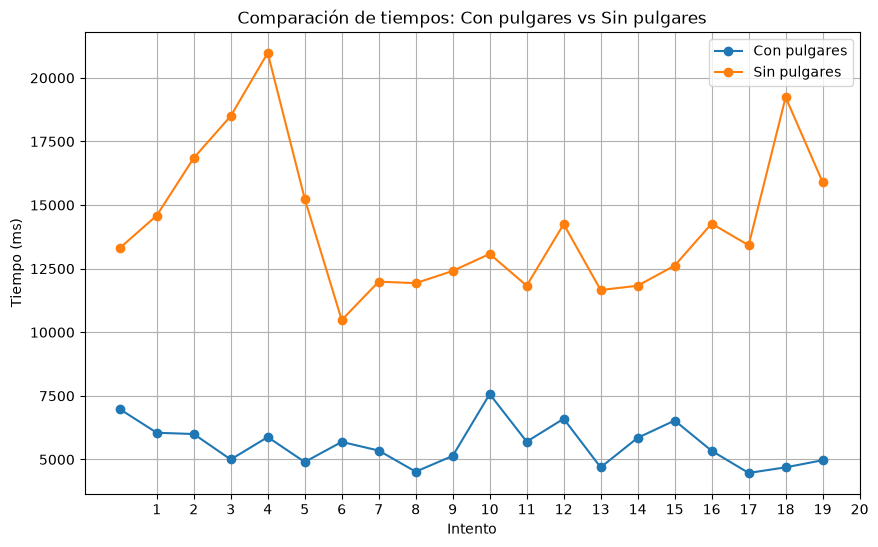

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(con_pulgares['Intento'], con_pulgares['Tiempo_ms'], marker='o', label='Con pulgares')
plt.plot(sin_pulgares['Intento'], sin_pulgares['Tiempo_ms'], marker='o', label='Sin pulgares')
plt.title('Comparación de tiempos: Con pulgares vs Sin pulgares')
plt.xlabel('Intento')
plt.ylabel('Tiempo (ms)')
plt.xticks(range(1, 21))
plt.legend()
plt.grid(True)
plt.show()

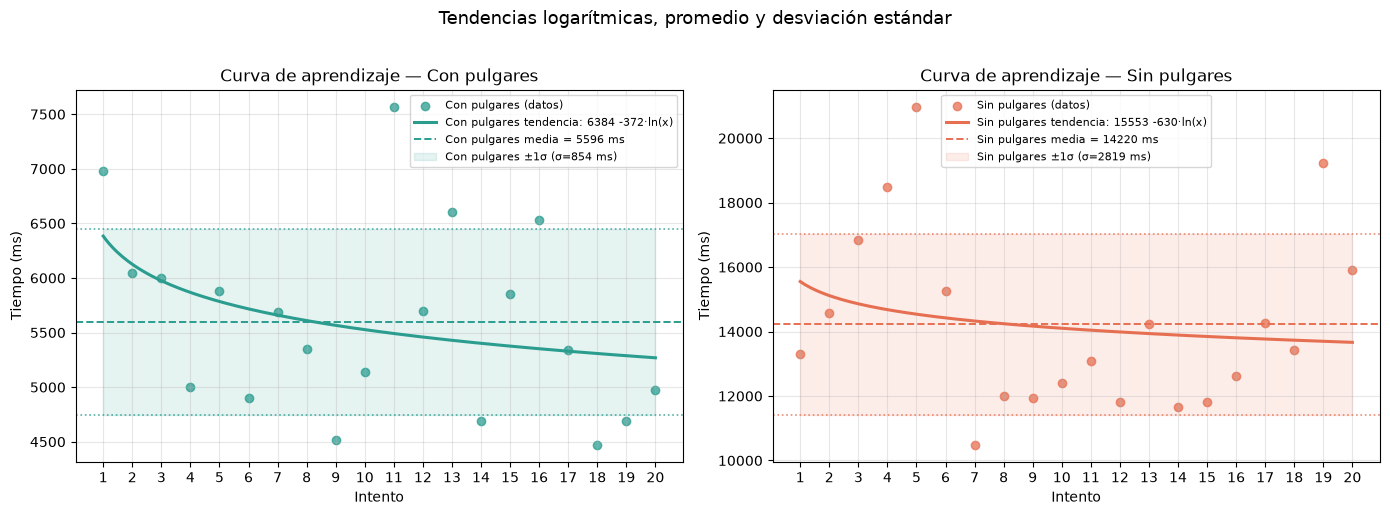

Con pulgares:
  Media = 5596.0 ms | Desv. est. = 854.1 ms
  Tendencia log: tiempo ≈ 6383.7 -372.1·ln(intento)
Sin pulgares:
  Media = 14219.5 ms | Desv. est. = 2818.6 ms
  Tendencia log: tiempo ≈ 15552.9 -629.9·ln(intento)


In [26]:
import numpy as np

def curva_aprendizaje(ax, df, etiqueta, color):
    """Grafica datos, tendencia logarítmica (con R²), media y ±1σ (dispersión, no aprendizaje)."""
    x = df['Intento'].to_numpy(dtype=float)
    y = df['Tiempo_ms'].to_numpy(dtype=float)

    media = y.mean()
    desv = y.std(ddof=1)

    # Ajuste logarítmico descriptivo: tiempo ≈ a + b·ln(intento)
    b, a = np.polyfit(np.log(x), y, 1)
    y_hat = a + b * np.log(x)
    r2 = 1 - ((y - y_hat) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    x_fit = np.linspace(x.min(), x.max(), 200)
    y_fit = a + b * np.log(x_fit)

    ax.scatter(x, y, color=color, alpha=0.75, label=f'{etiqueta} (datos)')
    ax.plot(
        x_fit, y_fit, color=color, linewidth=2.2,
        label=f'{etiqueta} log: {a:.0f} {b:+.0f}·ln(x) (R²={r2:.2f})',
    )
    ax.axhline(media, color=color, linestyle='--', linewidth=1.4,
               label=f'{etiqueta} media = {media:.0f} ms')
    # ±1σ describe dispersión global; no es evidencia de aprendizaje
    ax.axhline(media + desv, color=color, linestyle=':', linewidth=1.2, alpha=0.8)
    ax.axhline(media - desv, color=color, linestyle=':', linewidth=1.2, alpha=0.8)
    ax.fill_between(x_fit, media - desv, media + desv, color=color, alpha=0.12,
                     label=f'{etiqueta} ±1σ (dispersión, σ={desv:.0f} ms)')

    return media, desv, a, b, r2

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

media_con, desv_con, a_con, b_con, r2_con = curva_aprendizaje(
    axes[0], con_pulgares, 'Con pulgares', '#2a9d8f'
)
media_sin, desv_sin, a_sin, b_sin, r2_sin = curva_aprendizaje(
    axes[1], sin_pulgares, 'Sin pulgares', '#e76f51'
)

for ax, titulo in zip(axes, ['Con pulgares', 'Sin pulgares']):
    ax.set_title(f'Tendencia vs intento — {titulo}')
    ax.set_xlabel('Intento')
    ax.set_ylabel('Tiempo (ms)')
    ax.set_xticks(range(1, 21))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='best')

fig.suptitle(
    'Ajuste logarítmico (descriptivo), media y dispersión ±1σ',
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

print('Con pulgares:')
print(f'  Media = {media_con:.1f} ms | Desv. est. = {desv_con:.1f} ms')
print(f'  Log: tiempo ≈ {a_con:.1f} {b_con:+.1f}·ln(intento) | R² = {r2_con:.3f}')
print('Sin pulgares:')
print(f'  Media = {media_sin:.1f} ms | Desv. est. = {desv_sin:.1f} ms')
print(f'  Log: tiempo ≈ {a_sin:.1f} {b_sin:+.1f}·ln(intento) | R² = {r2_sin:.3f}')
print('Nota: R² bajo implica que el ajuste log no explica bien la serie; no basta para afirmar H2.')


### Pruebas de hipótesis (H1 y H2)

Estadísticos descriptivos, contraste entre condiciones (H1), pendiente e early vs late (H2), y comparación de varianzas.

In [ ]:
from scipy import stats

ALPHA = 0.05
y_con = con_pulgares['Tiempo_ms'].to_numpy(dtype=float)
y_sin = sin_pulgares['Tiempo_ms'].to_numpy(dtype=float)
x_con = con_pulgares['Intento'].to_numpy(dtype=float)
x_sin = sin_pulgares['Intento'].to_numpy(dtype=float)


def describir(nombre, y):
    q1, q3 = np.percentile(y, [25, 75])
    print(f'{nombre}:')
    print(
        f'  n={len(y)} | media={y.mean():.1f} | mediana={np.median(y):.1f} | '
        f'σ={y.std(ddof=1):.1f} | IQR={q3 - q1:.1f}'
    )


print('=== Descriptivos ===')
describir('Con pulgares', y_con)
describir('Sin pulgares', y_sin)

# --- H1: costo motor ---
aumento_pct = (y_sin.mean() - y_con.mean()) / y_con.mean() * 100
welch = stats.ttest_ind(y_sin, y_con, equal_var=False, alternative='greater')
mw = stats.mannwhitneyu(y_sin, y_con, alternative='greater')
# Cohen d (pooled)
pooled = np.sqrt((y_con.var(ddof=1) + y_sin.var(ddof=1)) / 2)
cohen_d = (y_sin.mean() - y_con.mean()) / pooled
# Rank-biserial a partir de Mann-Whitney (U de la muestra "sin")
n1, n2 = len(y_sin), len(y_con)
rank_biserial = (2 * mw.statistic) / (n1 * n2) - 1

print('\n=== H1 — Costo motor (sin > con) ===')
print(f'Aumento porcentual de la media: {aumento_pct:.1f}%')
print(f'Welch t (one-sided): t={welch.statistic:.3f}, p={welch.pvalue:.3e}')
print(f'Mann–Whitney U (one-sided): U={mw.statistic:.1f}, p={mw.pvalue:.3e}')
print(f'Cohen d ≈ {cohen_d:.2f} | rank-biserial ≈ {rank_biserial:.2f}')
print(
    'Decisión H1:',
    'RECHAZAR H0 (hay costo)' if mw.pvalue < ALPHA else 'NO rechazar H0',
)

# --- Variabilidad ---
levene = stats.levene(y_con, y_sin, center='median')
print('\n=== Variabilidad (Levene) ===')
print(f'Levene W={levene.statistic:.3f}, p={levene.pvalue:.3e}')
print(
    'Varianzas distintas:' if levene.pvalue < ALPHA else 'No se detecta diferencia de varianzas:',
    f'σ_con={y_con.std(ddof=1):.1f} vs σ_sin={y_sin.std(ddof=1):.1f}',
)


def prueba_h2(nombre, x, y):
    slope, intercept, r, p_two, se = stats.linregress(x, y)
    # H2: pendiente < 0 → p unilateral
    p_one = p_two / 2 if slope < 0 else 1 - p_two / 2
    early, late = y[:5].mean(), y[-5:].mean()
    delta_pct = (late - early) / early * 100
    print(f'\n--- H2 — {nombre} ---')
    print(
        f'Regresión lineal: pendiente={slope:.2f} ms/intento, '
        f'R²={r**2:.3f}, p (one-sided, slope<0)={p_one:.4f}'
    )
    print(f'Early(1–5) media={early:.1f} ms | Late(16–20) media={late:.1f} ms | Δ={delta_pct:+.1f}%')
    pendiente_ok = slope < 0 and p_one < ALPHA
    print(
        'Decisión H2 (criterio principal = pendiente significativa < 0):',
        'RECHAZAR H0 (mejora)' if pendiente_ok else 'NO rechazar H0 (sin mejora estadísticamente clara)',
    )
    if late < early and not pendiente_ok:
        print('  Nota: late < early en media, pero la pendiente no es significativa a α=0.05.')
    return slope, r**2, p_one, early, late, delta_pct


print('\n=== H2 — Mejora con la práctica ===')
prueba_h2('Con pulgares', x_con, y_con)
prueba_h2('Sin pulgares', x_sin, y_sin)


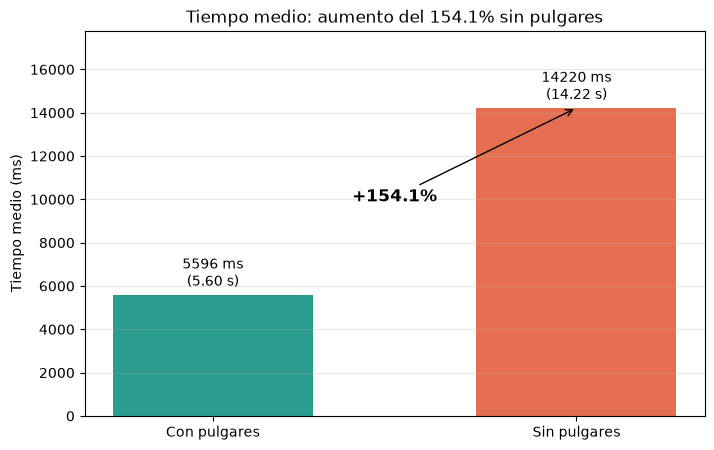

Media con pulgares: 5596.0 ms
Media sin pulgares: 14219.5 ms
Aumento porcentual: 154.1%


In [27]:
media_con = con_pulgares['Tiempo_ms'].mean()
media_sin = sin_pulgares['Tiempo_ms'].mean()
aumento_pct = (media_sin - media_con) / media_con * 100

escenarios = ['Con pulgares', 'Sin pulgares']
medias = [media_con, media_sin]
colores = ['#2a9d8f', '#e76f51']

plt.figure(figsize=(8, 5))
barras = plt.bar(escenarios, medias, color=colores, width=0.55)
plt.title(f'H1 — Tiempo medio global: +{aumento_pct:.1f}% sin pulgares')
plt.ylabel('Tiempo medio (ms)')
plt.grid(axis='y', alpha=0.3)

for barra, media in zip(barras, medias):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        media + 200,
        f'{media:.0f} ms\n({media/1000:.2f} s)',
        ha='center',
        va='bottom',
    )

# Flecha / anotación del aumento relativo
plt.annotate(
    f'+{aumento_pct:.1f}%',
    xy=(1, media_sin),
    xytext=(0.5, (media_con + media_sin) / 2),
    arrowprops=dict(arrowstyle='->', color='black'),
    ha='center',
    fontsize=12,
    fontweight='bold',
)

plt.ylim(0, media_sin * 1.25)
plt.show()

print(f'Media con pulgares: {media_con:.1f} ms')
print(f'Media sin pulgares: {media_sin:.1f} ms')
print(f'Aumento porcentual: {aumento_pct:.1f}%')


## Conclusiones

### Resultado estadístico

- **H1 (costo motor) — soportada.** Tiempo medio con pulgares: **5 596 ms** (~5,6 s); sin pulgares: **14 220 ms** (~14,2 s); aumento ≈ **154%**. Mann–Whitney y Welch (one-sided) son altamente significativos; el tamaño del efecto es muy grande (Cohen d ≈ 4). La restricción de pulgares degrada claramente el desempeño.
- **Variabilidad:** σ pasa de ~854 ms a ~2 819 ms; la prueba de Levene indica mayor dispersión sin pulgares. Eso es compatible con mayor dificultad/ruido, no por sí solo con “exploración estratégica”.
- **H2 (mejora con la práctica) — no soportada.** Las pendientes lineales no son significativas a α = 0,05 (con y sin pulgares). El ajuste log tiene R² bajo (~0,03–0,13). En sin pulgares, el bloque final (~15,1 s) no consolida una mejora frente al tramo medio y el último intento sigue alto: no hay curva de aprendizaje limpia.

### Idea pedagógica vs. hallazgo

Los pulgares importan mucho para la eficiencia de esta tarea. La **plasticidad / adaptación** es una hipótesis interesante para discutir en clase, pero **con estos datos no se puede afirmar** como resultado confirmado. Separar la narrativa motivacional del contraste estadístico evita sobreinterpretar.

### Limitaciones y réplica futura

- n = 1, cronómetro manual, orden fijo A→B (posible fatiga/transferencia).
- Para una réplica más sólida: contrabalanceo (o ABBA), descanso fijo entre condiciones, video o segundo observador, más intentos o más participantes, y bloques early/late **predefinidos** antes de ver los datos.
